## Balancing

---

Balancing data describes the electricity system's real-time balancing and
reserve mechanisms used to keep the grid in balance.

### Typical units

- Reserve Capacity Prices: `EUR/MW`
- Reserve Capacity `MW`
- Imbalance Volume: `MWh`
- Activated Balancing Energy: `MWh`
- Balancing/Imbalance Prices: `EUR/MWh`

### Typical applications

- Balancing-market analysis
- Reserve and Balancing-price forecasting
- Imbalance-cost analysis
- Renewable integration
- Battery/Storage optimisation
- Ancillary-service analysis
- Power-system flexibility assessment

---

# Config

---

In [84]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.style.use("ggplot")

import os
from dotenv import load_dotenv

from entsoe import EntsoePandasClient

load_dotenv()

# ENTSOE Token
entsoe_token = os.getenv("ENTSOE_API_TOKEN")

# ENTSOE Client
entsoe_client = EntsoePandasClient(api_key=entsoe_token)

# Settings

---

In [85]:
# Location
country_capital = "Madrid"
country_code = "ES"

# Period
tz = f"Europe/{country_capital}"

now = pd.Timestamp.now(tz=tz)
today = now.normalize()

yesterday = today - pd.Timedelta(days=1)
last_week = today - pd.Timedelta(days=7)
last_month = today - pd.DateOffset(months=1)

tomorrow = today + pd.Timedelta(days=1)
day_after_tomorrow = today + pd.Timedelta(days=2)
next_week = today + pd.Timedelta(days=7)
next_month = today + pd.DateOffset(months=1)

# EDA
---

###################################################################################
# .query_imbalance_volumes
(country_code, start=start, end=end, psr_type=None) -> pd.DataFrame

<p>Total aggregated volume of the energy deviation from the scheduled position.</p>

In [37]:
imbalance_volumes= entsoe_client.query_imbalance_volumes(
    country_code=country_code,
    start=last_week, 
    end=now, 
    psr_type=None
)

In [38]:
imbalance_volumes.info()

<class 'pandas.Series'>
DatetimeIndex: 757 entries, 2026-08-27 00:00:00+02:00 to 2026-09-03 21:00:00+02:00
Series name: Imbalance Volume
Non-Null Count  Dtype  
--------------  -----  
757 non-null    float64
dtypes: float64(1)
memory usage: 11.8 KB


In [39]:
imbalance_volumes.head()

2026-08-27 00:00:00+02:00    46.0
2026-08-27 00:15:00+02:00   -56.9
2026-08-27 00:30:00+02:00   -58.7
2026-08-27 00:45:00+02:00   -58.6
2026-08-27 01:00:00+02:00   -39.9
Name: Imbalance Volume, dtype: float64

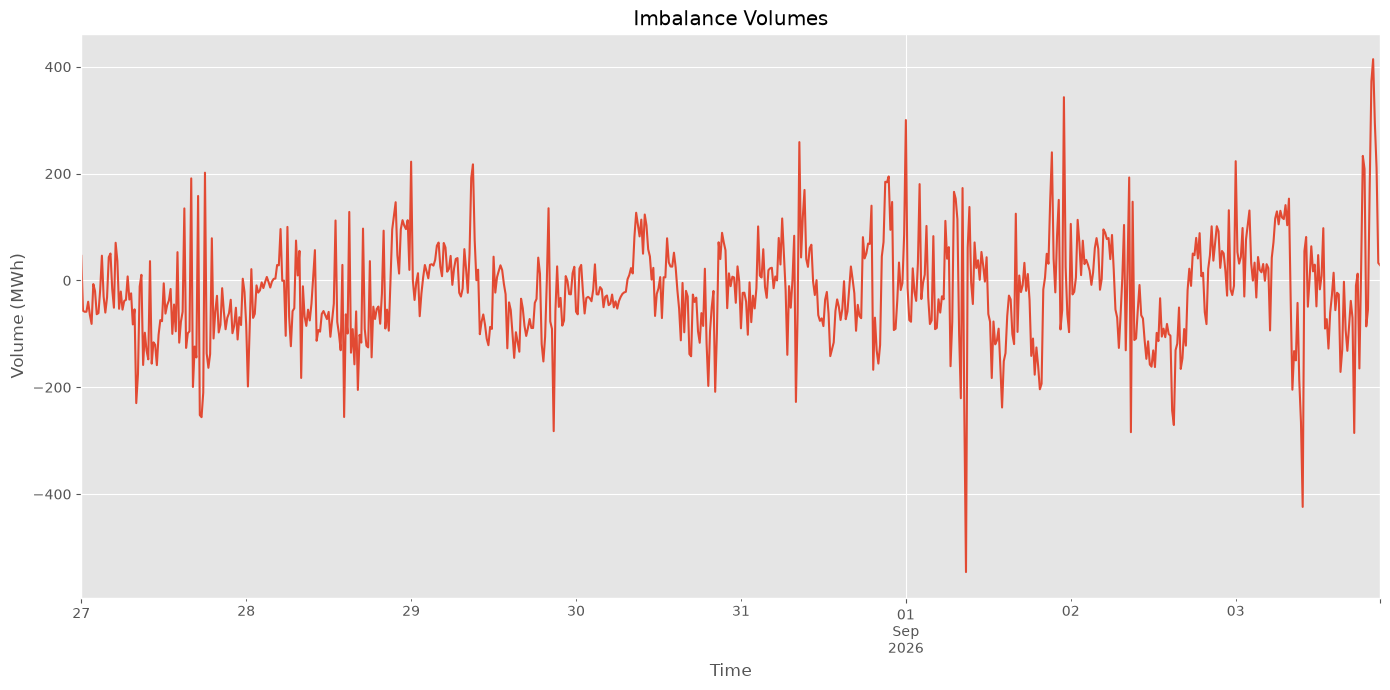

In [86]:
fig, ax = plt.subplots(figsize=(14, 7))

imbalance_volumes.plot(ax=ax)

ax.set_title("Imbalance Volumes")
ax.set_xlabel("Time")
ax.set_ylabel("Volume (MWh)")

fig.tight_layout()
plt.show()

###################################################################################
# .query_imbalance_prices
(country_code, start=start, end=end, psr_type=None) -> pd.DataFrame

<p>Prices used to financially settle a participant's deviation from its scheduled position</p>

In [41]:
imbalance_prices = entsoe_client.query_imbalance_prices(
    country_code=country_code,
    start=last_week,
    end=now,
    psr_type=None
)

In [42]:
imbalance_prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 757 entries, 2026-08-27 00:00:00+02:00 to 2026-09-03 21:00:00+02:00
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Long    757 non-null    float64
 1   Short   757 non-null    float64
dtypes: float64(2)
memory usage: 17.7 KB


In [43]:
imbalance_prices.head()

,Long,Short
2026-08-27 00:00:00+02:00,129.95,234.82
2026-08-27 00:15:00+02:00,109.23,207.38
2026-08-27 00:30:00+02:00,123.61,207.16
2026-08-27 00:45:00+02:00,124.18,206.83
2026-08-27 01:00:00+02:00,268.45,268.45


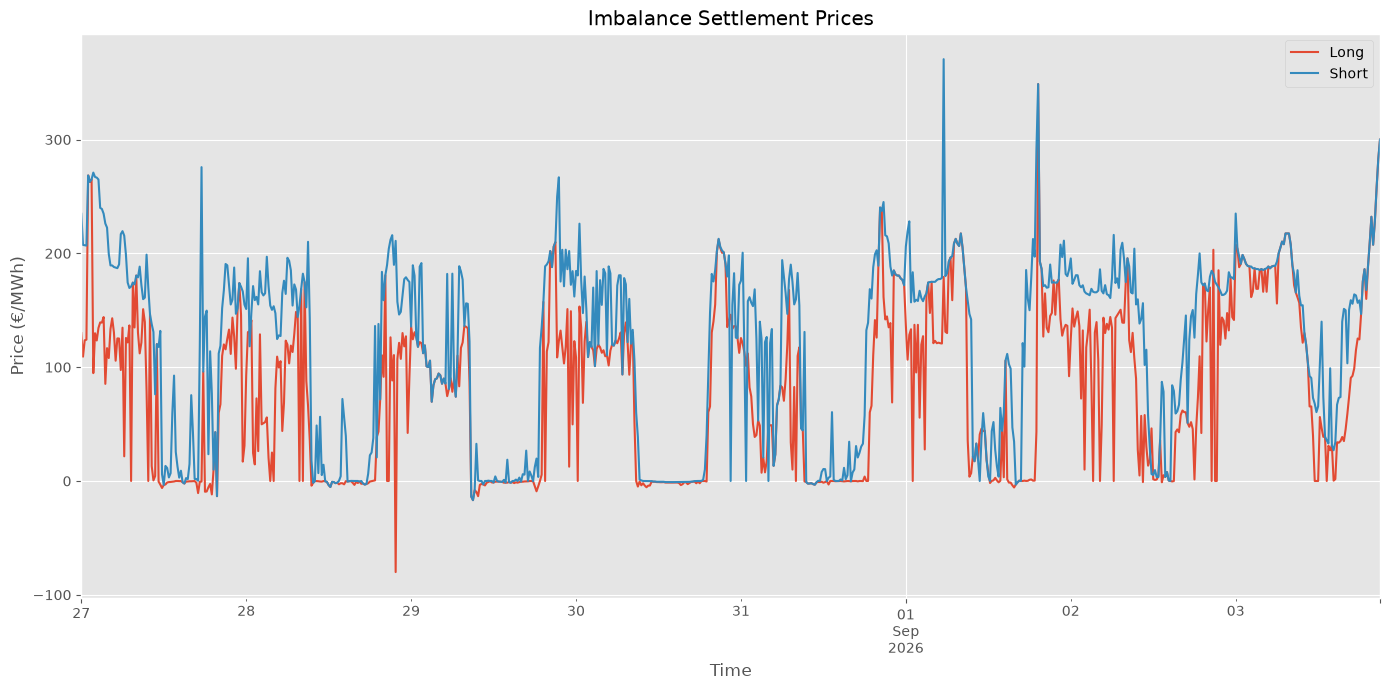

In [89]:
fig, ax = plt.subplots(figsize=(14, 7))

imbalance_prices.plot(ax=ax)

ax.set_title("Imbalance Settlement Prices")
ax.set_xlabel("Time")
ax.set_ylabel("Price (€/MWh)")

fig.tight_layout()
plt.show()

<p>The long and short columns represent the two imbalance directions from the system's perspective.</p>

`LONG` - price associated with a <b>surplus</b> (more energy was supplied than scheduled)

`SHORT` - price associated with a <b>deficit</b> (less energy was supplied than scheduled)

###################################################################################
# .query_procured_balancing_capacity
(country_code, process_type, start=start, end=end, type_marketagreement_type=None) -> pd.DataFrame

In [46]:
''' 'A46': 'Replacement reserve',
    'A47': 'Manual frequency restoration reserve',
    'A51': 'Automatic frequency restoration reserve',
    'A52': 'Frequency containment reserve',
    'A56': 'Frequency restoration reserve'
'''
aFRR = entsoe_client.query_procured_balancing_capacity(
    country_code=country_code,
    process_type="A51",
    start=last_week,
    end=today,
    type_marketagreement_type=None
)

In [47]:
aFRR.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 94 entries, 2026-08-27 00:00:00+02:00 to 2026-08-27 23:15:00+02:00
Columns: 400 entries, ('Down', np.int64(1), 'Price') to ('Up', np.int64(100), 'Volume')
dtypes: float64(400)
memory usage: 294.5 KB


In [49]:
aFRR.head().T

2026-08-27 00:00:00+02:00  2026-08-27 00:15:00+02:00  \
direction mrid unit                                                           
Down      1    Price                         NaN                       0.25   
               Volume                        NaN                      27.00   
          2    Price                         NaN                       0.86   
               Volume                        NaN                       2.00   
          3    Price                         NaN                       0.91   
...                                          ...                        ...   
Up        98   Volume                        NaN                        NaN   
          99   Price                         NaN                        NaN   
               Volume                        NaN                        NaN   
          100  Price                         NaN                        NaN   
               Volume                        NaN                        NaN   

                       2026-08-27 00:30:00+02:00  2026-08-27 00:45:00+02:00  \
direction mrid unit                                                           
Down      1    Price                         NaN                       0.83   
               Volume                        NaN                       5.00   
          2    Price                         NaN                       1.25   
               Volume                        NaN                      14.00   
          3    Price                         NaN                       0.98   
...                                          ...                        ...   
Up        98   Volume                        NaN                        NaN   
          99   Price                         NaN                        NaN   
               Volume                        NaN                        NaN   
          100  Price                         NaN                        NaN   
               Volume                        NaN                        NaN   

                       2026-08-27 01:00:00+02:00  
direction mrid unit                               
Down      1    Price                         NaN  
               Volume                        NaN  
          2    Price                         NaN  
               Volume                        NaN  
          3    Price                         NaN  
...                                          ...  
Up        98   Volume                        NaN  
          99   Price                         NaN  
               Volume                        NaN  
          100  Price                         NaN  
               Volume                        NaN  

[400 rows x 5 columns]

###################################################################################
# .query_activated_balancing_energy
(country_code, start=start, end=end, business_type, psr_type=None) -> pd.DataFrame

In [56]:
# activated_balancing_energy = entsoe_client.query_activated_balancing_energy(
#     country_code=country_code,
#     start=last_week,
#     end=next_week,
#     business_type="B04",
#     psr_type=None
# )

import inspect

print(inspect.signature(entsoe_client.query_activated_balancing_energy))

(country_code: entsoe.mappings.Area | str, start: pandas.Timestamp, end: pandas.Timestamp, business_type: str, psr_type: str | None = None) -> pandas.DataFrame


###################################################################################
# .query_activated_balancing_energy_prices
((country_code, start=start, end=end, process_type='A16', psr_type=None, business_type=None, standard_market_product=None, original_market_product=None))-> pd.DataFrame

<p>Prices paid by the TSO per type of procured balancing reserve and per procurement period.</p>

In [55]:
# activated_balancing_energy_prices = entsoe_client.query_activated_balancing_energy_prices(
#     country_code=country_code,
#     start=last_week,
#     end=yesterday,
#     process_type="A16",
#     psr_type=None,
#     business_type=None,
#     standard_market_product=None,
#     original_market_product=None
# )

###################################################################################
# .query_contracted_reserve_amount
(country_code, type_marketagreement_type, start=start, end=end, psr_type=None) -> pd.DataFrame

In [ ]:
import inspect

print(inspect.signature(entsoe_client.query_contracted_reserve_amount))

# for process_type in ["A52", "A51", "A47", "A46"]:
#     try:
#         df = entsoe_client.query_contracted_reserve_amount(
#             country_code=country_code,
#             process_type=process_type,
#             type_marketagreement_type="A01",
#             start=last_week,
#             end=today,
#             psr_type=None,
#         )
#         print(process_type, df.shape)
#     except Exception as e:
#         print(process_type, repr(e))

(country_code: entsoe.mappings.Area | str, process_type: str, type_marketagreement_type: str, start: pandas.Timestamp, end: pandas.Timestamp, psr_type: str | None = None, offset: int = 0) -> pandas.DataFrame


In [ ]:
process_types = {
    "A46": "Replacement reserve",
    "A47": "Manual frequency restoration reserve",
    "A51": "Automatic frequency restoration reserve",
    "A52": "Frequency containment reserve",
    "A56": "Frequency restoration reserve",
}

market_agreement_types = {
    "A01": "Daily",
    "A02": "Weekly",
    "A03": "Monthly",
    "A04": "Yearly",
    "A05": "Total",
    "A06": "Long term",
    "A07": "Intraday",
    "A13": "Hourly",
}

results = {}

for process_code, process_name in process_types.items():
    for market_code, market_name in market_agreement_types.items():
        try:
            df = entsoe_client.query_contracted_reserve_amount(
                country_code=country_code,
                process_type=process_code,
                type_marketagreement_type=market_code,
                start=last_week,
                end=today,
                psr_type=None,
            )

            results[(process_code, market_code)] = df

            print(
                f"{process_code} ({process_name}) | "
                f"{market_code} ({market_name}) -> "
                f"{df.shape}"
            )

        except Exception as e:
            print(
                f"{process_code} ({process_name}) | "
                f"{market_code} ({market_name}) -> "
                f"{type(e).__name__}: {e}"
            )

A46 (Replacement reserve) | A01 (Daily) -> NoMatchingDataError: 
A46 (Replacement reserve) | A02 (Weekly) -> NoMatchingDataError: 
A46 (Replacement reserve) | A03 (Monthly) -> NoMatchingDataError: 
A46 (Replacement reserve) | A04 (Yearly) -> NoMatchingDataError: 
A46 (Replacement reserve) | A05 (Total) -> HTTPError: 400 Client Error:  for url: https://web-api.tp.entsoe.eu/api?documentType=A81&businessType=B95&processType=A46&controlArea_Domain=10YES-REE------0&type_MarketAgreement.Type=A05&offset=0&securityToken=9bad7365-6181-4bcc-a4d2-d3edb5f6c9df&periodStart=202608262200&periodEnd=202609022200
A46 (Replacement reserve) | A06 (Long term) -> NoMatchingDataError: 
A46 (Replacement reserve) | A07 (Intraday) -> HTTPError: 400 Client Error:  for url: https://web-api.tp.entsoe.eu/api?documentType=A81&businessType=B95&processType=A46&controlArea_Domain=10YES-REE------0&type_MarketAgreement.Type=A07&offset=0&securityToken=9bad7365-6181-4bcc-a4d2-d3edb5f6c9df&periodStart=202608262200&periodEnd

In [57]:
aFRR_daily=entsoe_client.query_contracted_reserve_amount(
    country_code=country_code,
    process_type="A51",
    type_marketagreement_type="A01",
    start=last_week,
    end=today,
    psr_type=None,
)

In [58]:
aFRR_daily.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 673 entries, 2026-08-27 00:00:00+02:00 to 2026-09-03 00:00:00+02:00
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Down    673 non-null    float64
 1   Up      673 non-null    float64
dtypes: float64(2)
memory usage: 15.8 KB


In [59]:
aFRR_daily.head()

,Down,Up
2026-08-27 00:00:00+02:00,1100.0,1100.0
2026-08-27 00:15:00+02:00,1100.0,1100.0
2026-08-27 00:30:00+02:00,1100.0,1100.0
2026-08-27 00:45:00+02:00,1100.0,1100.0
2026-08-27 01:00:00+02:00,1000.0,1000.0


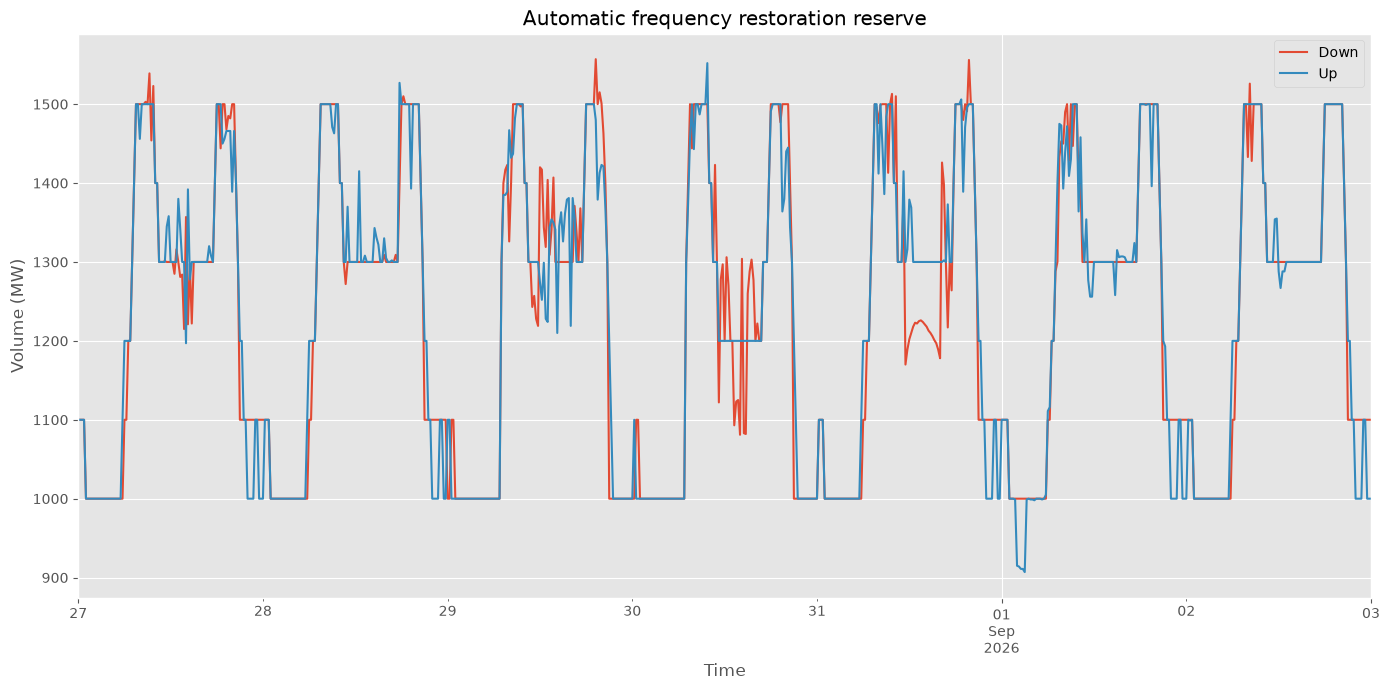

In [90]:
fig, ax = plt.subplots(figsize=(14, 7))

aFRR_daily.plot(ax=ax)

ax.set_title("Automatic frequency restoration reserve")
ax.set_xlabel("Time")
ax.set_ylabel("Volume (MW)")

fig.tight_layout()
plt.show()

In [66]:
mFRR_monthly=entsoe_client.query_contracted_reserve_amount(
    country_code=country_code,
    process_type="A47",
    type_marketagreement_type="A03",
    start=last_week,
    end=today,
    psr_type=None,
)

In [67]:
mFRR_monthly.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 673 entries, 2026-08-27 00:00:00+02:00 to 2026-09-03 00:00:00+02:00
Freq: 15min
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Down    673 non-null    float64
dtypes: float64(1)
memory usage: 10.5 KB


In [68]:
mFRR_monthly.head()

,Down
2026-08-27 00:00:00+02:00,1775.0
2026-08-27 00:15:00+02:00,1775.0
2026-08-27 00:30:00+02:00,1775.0
2026-08-27 00:45:00+02:00,1775.0
2026-08-27 01:00:00+02:00,1775.0


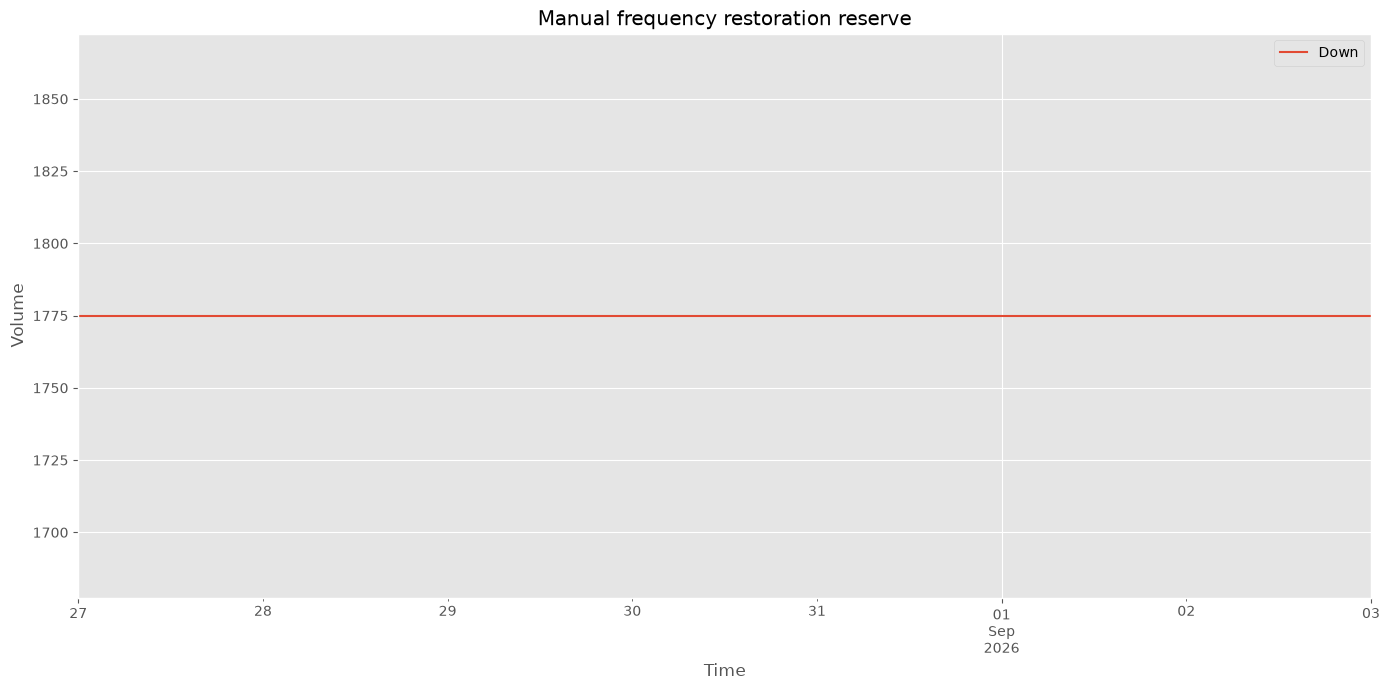

In [69]:
fig, ax = plt.subplots(figsize=(14, 7))

mFRR_monthly.plot(ax=ax)

ax.set_title("Manual frequency restoration reserve")
ax.set_xlabel("Time")
ax.set_ylabel("Volume")

fig.tight_layout()
plt.show()

###################################################################################
# .query_contracted_reserve_prices
(country_code, type_marketagreement_type, start=start, end=end, psr_type=None) -> pd.DataFrame

In [62]:
aFRR_daily_prices=entsoe_client.query_contracted_reserve_prices(
    country_code=country_code,
    process_type="A51",
    type_marketagreement_type="A01",
    start=last_week,
    end=today,
    psr_type=None,
)

In [63]:
aFRR_daily_prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 673 entries, 2026-08-27 00:00:00+02:00 to 2026-09-03 00:00:00+02:00
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Down    673 non-null    float64
 1   Up      673 non-null    float64
dtypes: float64(2)
memory usage: 15.8 KB


In [64]:
aFRR_daily_prices.head()

,Down,Up
2026-08-27 00:00:00+02:00,1.5,7.33
2026-08-27 00:15:00+02:00,1.5,7.60
2026-08-27 00:30:00+02:00,1.5,7.23
2026-08-27 00:45:00+02:00,1.5,6.30
2026-08-27 01:00:00+02:00,1.5,6.05


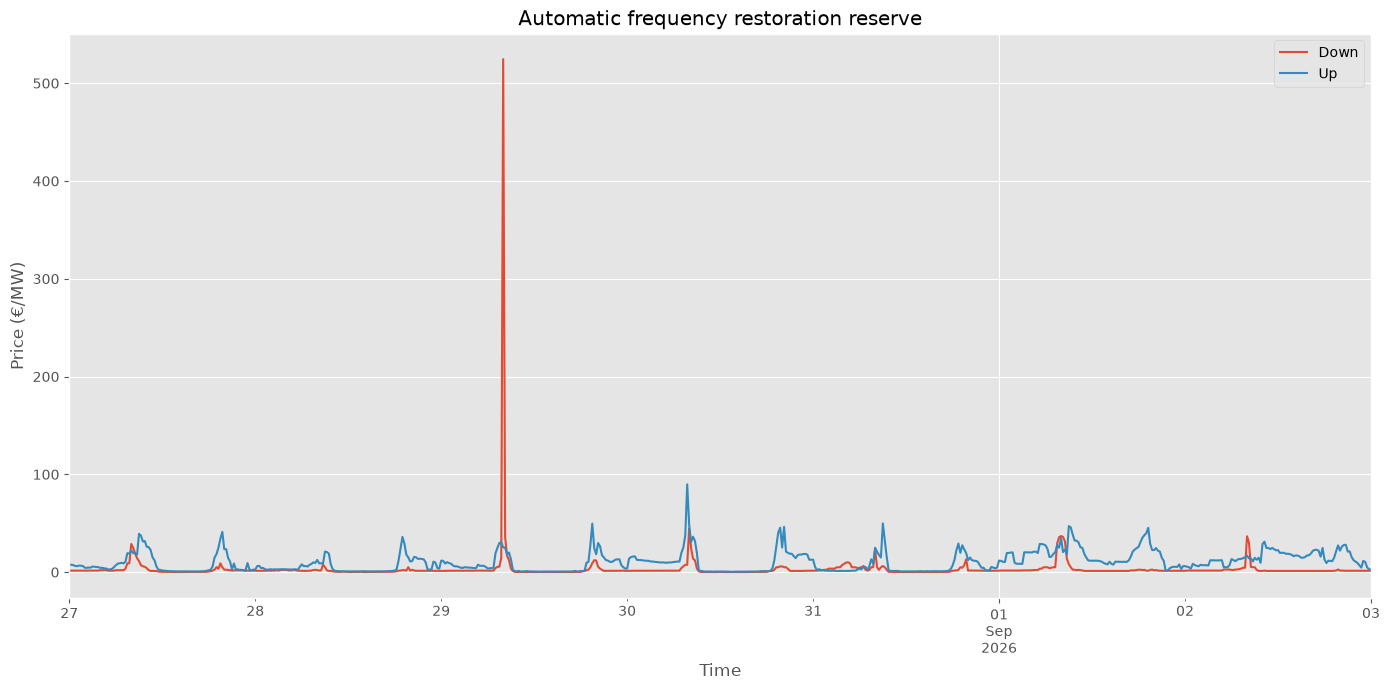

In [91]:
fig, ax = plt.subplots(figsize=(14, 7))

aFRR_daily_prices.plot(ax=ax)

ax.set_title("Automatic frequency restoration reserve")
ax.set_xlabel("Time")
ax.set_ylabel("Price (€/MW)")

fig.tight_layout()
plt.show()

###################################################################################
# .query_unavailability_of_generation_units
(country_code, start=start, end=end, docstatus=None, periodstartupdate=None, periodendupdate=None) -> pd.DataFrame

In [70]:
unavailability_of_generation_units = entsoe_client.query_unavailability_of_generation_units(
    country_code=country_code, 
    start=last_week, 
    end=today, 
    docstatus=None, 
    periodstartupdate=None, 
    periodendupdate=None
)

In [71]:
unavailability_of_generation_units.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 92 entries, 2025-10-08 10:08:50+02:00 to 2026-09-03 09:05:20+02:00
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype                        
---  ------                        --------------  -----                        
 0   avail_qty                     92 non-null     str                          
 1   biddingzone_domain            92 non-null     str                          
 2   businesstype                  92 non-null     str                          
 3   curvetype                     92 non-null     str                          
 4   docstatus                     0 non-null      object                       
 5   end                           92 non-null     datetime64[us, Europe/Madrid]
 6   mrid                          92 non-null     str                          
 7   nominal_power                 91 non-null     float64                      
 8   plant_type                    92 non-null  

In [72]:
unavailability_of_generation_units.head().T

created_doc_time,2025-10-08 10:08:50+02:00,2025-10-08 10:08:50+02:00,2025-10-08 10:08:51+02:00,2025-10-08 10:08:51+02:00,2025-11-10 16:06:39+01:00
avail_qty,0,0,0,0,0
biddingzone_domain,ES,ES,ES,ES,ES
businesstype,Planned maintenance,Planned maintenance,Planned maintenance,Planned maintenance,Planned maintenance
curvetype,A03,A03,A03,A03,A03
docstatus,None,None,None,None,None
end,2026-08-28 00:00:00+02:00,2026-08-28 00:00:00+02:00,2026-08-28 00:00:00+02:00,2026-08-28 00:00:00+02:00,2026-10-31 00:00:00+01:00
mrid,CNY96Ljl3cmlHtrSk1eqow,o-bWWIxY5w-x2I7_eyILoA,7EzbPTHJBzwrgrkxExNjSw,IhVBMcq73RrJLQeEP9zWUQ,7bKnUFc-Dp_SK6HbWu_4Tg
nominal_power,109.8,100.0,100.0,109.8,392.6
plant_type,Hydro Pumped Storage,Hydro Pumped Storage,Hydro Pumped Storage,Hydro Pumped Storage,Fossil Gas
production_resource_id,18WSLTG-12345-0T,18WSLTB-12345-05,18WSLTB-12345-05,18WSLTG-12345-0T,18WCAMGI10-12-07


###################################################################################
# .query_unavailability_of_production_units
(country_code, start, end, docstatus=None, periodstartupdate=None, periodendupdate=None) -> pd.DataFrame

In [73]:
unavailability_of_production_units = entsoe_client.query_unavailability_of_production_units(
    country_code=country_code, 
    start=last_week, 
    end=today, 
    docstatus=None, 
    periodstartupdate=None, 
    periodendupdate=None
)

In [74]:
unavailability_of_production_units.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 79 entries, 2025-11-28 14:52:35+01:00 to 2026-09-03 18:13:56+02:00
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype                        
---  ------                        --------------  -----                        
 0   avail_qty                     79 non-null     str                          
 1   biddingzone_domain            79 non-null     str                          
 2   businesstype                  79 non-null     str                          
 3   curvetype                     79 non-null     str                          
 4   docstatus                     0 non-null      object                       
 5   end                           79 non-null     datetime64[us, Europe/Madrid]
 6   mrid                          79 non-null     str                          
 7   nominal_power                 79 non-null     float64                      
 8   plant_type                    79 non-null  

In [75]:
unavailability_of_production_units.head().T

created_doc_time,2025-11-28 14:52:35+01:00,2025-11-28 14:52:37+01:00,2025-11-28 14:52:40+01:00,2025-11-28 14:52:41+01:00,2025-11-28 14:52:54+01:00
avail_qty,470.9,0,219.6,200,1403
biddingzone_domain,ES,ES,ES,ES,ES
businesstype,Planned maintenance,Planned maintenance,Planned maintenance,Planned maintenance,Planned maintenance
curvetype,A03,A03,A03,A03,A03
docstatus,None,None,None,None,None
end,2026-09-29 00:00:00+02:00,2026-10-10 00:00:00+02:00,2026-08-28 00:00:00+02:00,2026-08-28 00:00:00+02:00,2026-08-31 00:00:00+02:00
mrid,W8hleaF265q8SFPj7uZmDw,V67XFIuESXvPBrexBJVN1g,hVoJdXdughdIeG3agmUDRg,6TPCsLwhBYk8N2NEFBocOA,xCy4re6HqZHDiXMW3QA26g
nominal_power,625.9,420.0,439.2,400.0,1857.7
plant_type,Hydro Water Reservoir,Hydro Pumped Storage,Hydro Pumped Storage,Hydro Pumped Storage,Hydro Water Reservoir
production_resource_id,18WSBEU-12345-0Q,18WTJEB-12345-0X,18WSLTG-12345-0T,18WSLTB-12345-05,18WEBRFEN-123-0T


###################################################################################
# .query_unavailability_transmission
(country_code_from, country_code_to, start=start, end=end, docstatus=None, periodstartupdate=None, periodendupdate=None) -> pd.DataFrame

In [76]:
unavailability_transmissions_spain_to_france = entsoe_client.query_unavailability_transmission(
    country_code_from="ES",
    country_code_to="FR",
    start=last_week, 
    end=today, 
    docstatus=None, 
    periodstartupdate=None, 
    periodendupdate=None
)

In [77]:
unavailability_transmissions_spain_to_france.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 477 entries, 2025-12-01 11:30:14+01:00 to 2026-09-03 21:12:21+02:00
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype                        
---  ------        --------------  -----                        
 0   docstatus     2 non-null      object                       
 1   mrid          477 non-null    str                          
 2   revision      477 non-null    int64                        
 3   businesstype  477 non-null    str                          
 4   in_domain     477 non-null    str                          
 5   out_domain    477 non-null    str                          
 6   qty_uom       477 non-null    str                          
 7   curvetype     477 non-null    str                          
 8   start         477 non-null    datetime64[us, Europe/Madrid]
 9   end           477 non-null    datetime64[us, Europe/Madrid]
 10  resolution    477 non-null    str                          
 11  pstn   

In [78]:
unavailability_transmissions_spain_to_france.head().T

created_doc_time,2025-12-01 11:30:14+01:00,2025-12-01 11:30:14+01:00,2025-12-01 11:30:14+01:00,2025-12-01 11:32:42+01:00,2025-12-01 11:32:42+01:00
docstatus,None,None,None,None,None
mrid,wAb4T-TR-PDXJbelKnaqrg,wAb4T-TR-PDXJbelKnaqrg,wAb4T-TR-PDXJbelKnaqrg,JewQ2pv_Lg01o5y3f41vVg,JewQ2pv_Lg01o5y3f41vVg
revision,1,1,1,1,1
businesstype,Planned maintenance,Planned maintenance,Planned maintenance,Planned maintenance,Planned maintenance
in_domain,FR,FR,FR,FR,FR
out_domain,ES,ES,ES,ES,ES
qty_uom,MAW,MAW,MAW,MAW,MAW
curvetype,A03,A03,A03,A03,A03
start,2026-08-24 07:00:00+02:00,2026-08-28 23:59:00+02:00,2026-08-30 23:59:00+02:00,2026-08-28 23:59:00+02:00,2026-08-17 08:00:00+02:00
end,2026-08-28 23:59:00+02:00,2026-08-30 23:59:00+02:00,2026-08-31 23:00:00+02:00,2026-08-30 23:59:00+02:00,2026-08-28 23:59:00+02:00


###################################################################################
# .query_withdrawn_unavailability_of_generation_units
(country_code, start, end) -> pd.DataFrame

In [79]:
withdrawn_unavailability_of_generation_units = entsoe_client.query_withdrawn_unavailability_of_generation_units(
    country_code=country_code, 
    start=last_week, 
    end=today
)

In [80]:
withdrawn_unavailability_of_generation_units.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 39 entries, 2026-02-24 15:15:15+01:00 to 2026-09-02 17:47:33+02:00
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype                        
---  ------                        --------------  -----                        
 0   avail_qty                     39 non-null     str                          
 1   biddingzone_domain            39 non-null     str                          
 2   businesstype                  39 non-null     str                          
 3   curvetype                     39 non-null     str                          
 4   docstatus                     39 non-null     str                          
 5   end                           39 non-null     datetime64[us, Europe/Madrid]
 6   mrid                          39 non-null     str                          
 7   nominal_power                 39 non-null     float64                      
 8   plant_type                    39 non-null  

In [81]:
withdrawn_unavailability_of_generation_units.head().T

created_doc_time,2026-02-24 15:15:15+01:00,2026-03-27 02:48:06+01:00,2026-08-22 10:40:32+02:00,2026-08-27 21:08:08+02:00,2026-08-27 21:27:40+02:00
avail_qty,151.3,124,265,210,90
biddingzone_domain,ES,ES,ES,ES,ES
businesstype,Unplanned outage,Unplanned outage,Unplanned outage,Unplanned outage,Unplanned outage
curvetype,A03,A03,A03,A03,A03
docstatus,Withdrawn,Withdrawn,Withdrawn,Withdrawn,Withdrawn
end,2026-10-01 00:00:00+02:00,2026-10-01 00:00:00+02:00,2026-09-01 00:00:00+02:00,2026-08-27 19:40:00+02:00,2026-08-27 20:37:00+02:00
mrid,Wcivt3WtHqh9CU7MAClkHQ,oUrFHCOxKFLpZ3q4AHiCew,PbxiaB0hGomKpg2GhTJnOg,WMxIKkTSXdUrzS7vlREMyg,cyLplfhqPv1p_e99aekGgg
nominal_power,302.7,302.7,411.9,399.7,399.7
plant_type,Fossil Gas,Fossil Gas,Fossil Gas,Fossil Gas,Fossil Gas
production_resource_id,18WPGR5-123456-J,18WPGR5-123456-J,18WBES3-12345-0V,18WBES4-12345-0L,18WBES4-12345-0L


###################################################################################
# .query_unavailability_of_offshore_grid
(area_code, start, end) -> pd.DataFrame

In [83]:
# unavailability_of_offshore_grid = entsoe_client.query_unavailability_of_offshore_grid(
#     area_code="FR",
#     start=last_week,
#     end=today
# )